<a href="https://colab.research.google.com/github/luquelab/Flyby-Denial/blob/draft/Copy_of_Final_Ngoc_Tao_draft_bioinformatic_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install and import packages

In [ ]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import collections # Added for Counter
import zipfile
import os

from google.colab import files
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler

# Install Biopython
!pip install biopython

# Install xlsxwriter for Excel export
!pip install xlsxwriter

from Bio import SeqIO # Import SeqIO for parsing FASTA files
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio import ExPASy
from Bio import SwissProt
from Bio import Align
from Bio.Seq import Seq # Added for creating Seq objects
from Bio.SeqRecord import SeqRecord # Added for creating SeqRecord objects

# Input data

## Option 1: Upload a FASTA file
You can upload one or more FASTA files from your local machine using the following code:

In [ ]:

# Upload one or more FASTA files
print("Please select your FASTA files for upload:")
uploaded = files.upload()

# This list will store all SeqRecord objects from all uploaded FASTA files
all_fasta_sequences = []

print("\n--- Processing uploaded FASTA files ---")
for filename in uploaded.keys():
    print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')
    with open(filename, 'wb') as f:
        f.write(uploaded[filename])

    try:
        # Read sequences from the current FASTA file
        sequences_from_file = list(SeqIO.parse(filename, "fasta"))
        print(f"Loaded {len(sequences_from_file)} sequences from {filename}")
        all_fasta_sequences.extend(sequences_from_file) # Add to the master list

        # Print a few details for confirmation
        for i, seq_record in enumerate(sequences_from_file[:3]): # Show first 3 sequences from this file
            print(f"  Sample from {filename}: ID: {seq_record.id}, Length: {len(seq_record.seq)}")
            if len(seq_record.seq) > 50:
                print(f"  Sequence preview: {str(seq_record.seq)[:50]}...\n")
            else:
                print(f"  Sequence preview: {str(seq_record.seq)}\n")

    except Exception as e:
        print(f"Error reading FASTA file {filename}: {e}")

print(f"Total sequences loaded from all uploaded FASTA files: {len(all_fasta_sequences)} SeqRecords.")

# Now, `all_fasta_sequences` contains SeqRecord objects from all uploaded files and can be used by subsequent cells.


## Option 2: Enter protein sequence manually

If you have a protein sequence readily available, you can directly paste it here. Make sure it's a raw protein sequence (amino acid letters only, no FASTA headers).

In [ ]:


# Ensure all_fasta_sequences exists and is a list
if 'all_fasta_sequences' not in globals() or not isinstance(all_fasta_sequences, list):
    all_fasta_sequences = []
    print("Initialized 'all_fasta_sequences' list for manually entered sequences.")

print("Please enter your protein sequences one by one. Press Enter on an empty line to finish.")

sequence_count = 0
while True:
    user_sequence_input = input(f"Enter protein sequence (or press Enter to finish): ")

    if not user_sequence_input.strip(): # Check for empty input to break the loop
        print("No more sequences to add. Finishing manual input.")
        break

    # Clean the input sequence (remove spaces, newlines, etc.)
    cleaned_sequence = user_sequence_input.strip().replace(' ', '').replace('\n', '').replace('\r', '')

    if cleaned_sequence:
        try:
            sequence_count += 1
            # Create a Seq object
            protein_seq = Seq(cleaned_sequence)
            # Create a SeqRecord object. Assign a generic ID if no specific one is provided.
            new_seq_record = SeqRecord(protein_seq, id=f"User_Input_Protein_{sequence_count}", description="Manually entered sequence")

            all_fasta_sequences.append(new_seq_record)
            print(f"  Added sequence {sequence_count}: ID: {new_seq_record.id}, Length: {len(new_seq_record.seq)}")
            if len(new_seq_record.seq) > 50:
                print(f"  Sequence preview: {str(new_seq_record.seq)[:50]}...\n")
            else:
                print(f"  Sequence preview: {str(new_seq_record.seq)}\n")

        except Exception as e:
            print(f"Error processing manual sequence input: {e}")
    else:
        print("No valid sequence entered. Please try again or press Enter to finish.")

print(f"Total sequences loaded from manual input: {sequence_count} SeqRecords. Current total in all_fasta_sequences: {len(all_fasta_sequences)}.")

# Note: Previous content for fetching from NCBI has been removed as per user request.

## Option 3: Fetch from NCBI by Organism and Select FASTA files

This option allows you to search for protein sequences from the NCBI database by specifying an organism name. You can then view the results and select which sequences you'd like to include in your analysis.

### Initialization

This cell initializes the `all_fasta_sequences` list to ensure it's ready for new entries. It also configures Biopython's Entrez module with your email address, which is required for accessing NCBI databases, and prompts you to enter the organism name for your search.

In [25]:
# Ensure all_fasta_sequences exists and is a list
if 'all_fasta_sequences' not in globals() or not isinstance(all_fasta_sequences, list):
    all_fasta_sequences = []
    print("Initialized 'all_fasta_sequences' list for fetched sequences.")

print("\n--- Configure Entrez and Input Organism Name ---")

# Configure Entrez for NCBI access
# Replace "your.email@example.com" with your actual email address
from Bio import Entrez
Entrez.email = "your.email@example.com"

organism_name = input("Enter organism name (e.g., 'Homo sapiens', 'Mus musculus'): ")


--- Configure Entrez and Input Organism Name ---
Enter organism name (e.g., 'Homo sapiens', 'Mus musculus'): Mus musculus


### NCBI database search

This cell searches the NCBI protein database for protein IDs corresponding to the organism name you provided. It then populates the `protein_ids` list with the identifiers found.

In [26]:
protein_ids = [] # Initialize protein_ids

if organism_name:
    try:
        print(f"Searching for protein IDs for '{organism_name}'...")
        # Search for protein IDs in the protein database for the specified organism
        handle = Entrez.esearch(db="protein", term=f"{organism_name}[Organism]", retmax="1000")
        record = Entrez.read(handle)
        handle.close()
        protein_ids = record["IdList"]

        if not protein_ids:
            print(f"No protein sequences found for '{organism_name}'. Please try a different organism or check spelling.")
        else:
            print(f"Found {len(protein_ids)} protein IDs for '{organism_name}'.")

    except Exception as e:
        print(f"An error occurred during NCBI search: {e}")
else:
    print("No organism name entered. Skipping NCBI search.")

Searching for protein IDs for 'Mus musculus'...
Found 1000 protein IDs for 'Mus musculus'.


### Display protein description

This cell fetches summary information for the found `protein_ids` and displays a numbered list of available sequences along with their descriptions. This helps you review the proteins before selection.

In [27]:
available_sequences = [] # Initialize available_sequences

if protein_ids:
    try:
        print("\n--- Fetching Summaries and Displaying Available Sequences ---")
        # Fetch summaries for a better description
        print("Fetching summaries...")
        handle_summary = Entrez.esummary(db="protein", id=",".join(protein_ids))
        summary_records = Entrez.read(handle_summary)
        handle_summary.close()

        # Create a map for quicker lookup and robustness
        summary_map = {}
        for s_rec in summary_records:
            gi_from_summary = str(s_rec['Id'])
            if 'Title' in s_rec:
                summary_map[gi_from_summary] = s_rec['Title']
            else:
                summary_map[gi_from_summary] = "No title available"

        print("\nAvailable sequences (ID - Description):")
        for i, protein_id in enumerate(protein_ids):
            description = summary_map.get(protein_id, "No description available")
            available_sequences.append({'id': protein_id, 'description': description})
            print(f"  [{i+1}] {protein_id} - {description}")

    except Exception as e:
        print(f"An error occurred during NCBI summary fetching: {e}")
else:
    print("No protein IDs to fetch summaries for.")


--- Fetching Summaries and Displaying Available Sequences ---
Fetching summaries...

Available sequences (ID - Description):
  [1] 13626032 - beta-klotho [Mus musculus]
  [2] 2719985038 - protein TESPA1 isoform c [Mus musculus]
  [3] 2719984964 - protein TESPA1 isoform a [Mus musculus]
  [4] 2719984932 - protein TESPA1 isoform c [Mus musculus]
  [5] 2719984737 - protein TESPA1 isoform d [Mus musculus]
  [6] 2719984531 - protein TESPA1 isoform b [Mus musculus]
  [7] 2719984377 - protein TESPA1 isoform a [Mus musculus]
  [8] 2719984304 - protein TESPA1 isoform a [Mus musculus]
  [9] 2719984289 - protein TESPA1 isoform a [Mus musculus]
  [10] 2636059576 - serine palmitoyltransferase 1 isoform 5 [Mus musculus]
  [11] 2636059516 - serine palmitoyltransferase 1 isoform 2 [Mus musculus]
  [12] 2636059514 - serine palmitoyltransferase 1 isoform 4 [Mus musculus]
  [13] 2635254704 - serine palmitoyltransferase 1 isoform 6 [Mus musculus]
  [14] 2635254698 - serine palmitoyltransferase 1 isoform 

### Enter the specific protein ID(s)

Use this cell to select the specific protein sequences you wish to fetch. You can enter individual IDs separated by commas, or type 'all' to include all displayed sequences. The selected IDs will be stored in `selected_ids_to_fetch`.

In [28]:
selected_ids_to_fetch = [] # Initialize selected_ids_to_fetch

if available_sequences:
    print("\n--- Select Sequences for Fetching ---")
    selected_ids_input = input("Enter the IDs of the sequences you want to fetch (e.g., '13626032,2719985038' or 'all'): ")

    if selected_ids_input.lower() == 'all':
        selected_ids_to_fetch = [seq['id'] for seq in available_sequences] # Get all IDs from available sequences
        print(f"Selected all {len(selected_ids_to_fetch)} sequences.")
    elif selected_ids_input.strip():
        entered_ids = [x.strip() for x in selected_ids_input.split(',') if x.strip()]

        # Get a list of all actual IDs that were available from the search
        actual_available_ids = [seq['id'] for seq in available_sequences]

        # Validate entered_ids against the list of actual available IDs
        valid_ids = [pid for pid in entered_ids if pid in actual_available_ids]
        invalid_ids = [pid for pid in entered_ids if pid not in actual_available_ids]

        if valid_ids:
            selected_ids_to_fetch.extend(valid_ids)
            print(f"Selected {len(valid_ids)} valid sequences based on your input.")
        if invalid_ids:
            print(f"Warning: The following entered IDs were not found in the available search results and skipped: {', '.join(invalid_ids)}")
        if not valid_ids and not invalid_ids:
            print("No valid sequence IDs entered. No sequences will be fetched.")
    else:
        print("No sequence IDs entered. No sequences will be fetched.")
else:
    print("No available sequences to select from.")


--- Select Sequences for Fetching ---
Enter the IDs of the sequences you want to fetch (e.g., '13626032,2719985038' or 'all'): 67466862,71151790
Selected 2 valid sequences based on your input.


### Fetching

This cell fetches the actual FASTA sequences for the protein IDs you selected in the previous step. It then parses these sequences and adds them to the `all_fasta_sequences` list, making them available for downstream analysis.

In [29]:
if selected_ids_to_fetch:
    try:
        print(f"\n--- Fetching FASTA Sequences ---")
        print(f"Fetching FASTA sequences for {len(selected_ids_to_fetch)} selected proteins...")
        # Fetch the actual FASTA sequences
        fasta_handle = Entrez.efetch(db="protein", id=",".join(selected_ids_to_fetch), rettype="fasta", retmode="text")
        fasta_records = fasta_handle.read() # Read content before closing
        fasta_handle.close()

        # Parse the FASTA data into SeqRecord objects
        # Using StringIO to treat the string as a file
        from io import StringIO
        fetched_sequences = list(SeqIO.parse(StringIO(fasta_records), "fasta"))

        all_fasta_sequences.extend(fetched_sequences)
        print(f"Successfully fetched {len(fetched_sequences)} sequences. Total sequences in all_fasta_sequences: {len(all_fasta_sequences)}.")
        for seq_record in fetched_sequences[:3]: # Show first 3 fetched sequences
            print(f"  Fetched Sample: ID: {seq_record.id}, Length: {len(seq_record.seq)}")
            if len(seq_record.seq) > 50:
                print(f"  Sequence preview: {str(seq_record.seq)[:50]}...\n")
            else:
                print(f"  Sequence preview: {str(seq_record.seq)}\n")
    except Exception as e:
        print(f"An error occurred during NCBI FASTA fetching: {e}")
else:
    print("No sequences selected for FASTA fetching.")

print(f"Current total sequences in all_fasta_sequences after NCBI fetch: {len(all_fasta_sequences)} SeqRecords.")


--- Fetching FASTA Sequences ---
Fetching FASTA sequences for 2 selected proteins...
Successfully fetched 2 sequences. Total sequences in all_fasta_sequences: 2.
  Fetched Sample: ID: sp|P59281.2|RHG39_MOUSE, Length: 1107
  Sequence preview: MSQAQDYECRSHHVDEQEPRIPGSSTRLEWVEIIEPRTRERMYANLVTGE...

  Fetched Sample: ID: sp|Q6PFD5.1|DLGP3_MOUSE, Length: 977
  Sequence preview: MRGYHGDRGSHPRPARFADQQHMDVGPAARAPYLLGSREAFSTEPRFCAP...

Current total sequences in all_fasta_sequences after NCBI fetch: 2 SeqRecords.


# Calculate Physicochemical Properties of Proteins

Using Biopython's `ProtParam` module, we can calculate various physicochemical properties of a protein sequence, such as its amino acid length, molecular weight, amino acid composition, isoelectric point, net charge, and extinction coefficient.

In [30]:
sequences_for_analysis_prep = []
# This list will store dictionaries, each containing protein info, its ProteinAnalysis object, and its properties
protein_data_for_analysis = []

# --- Rely solely on all_fasta_sequences which should now contain both uploaded and fetched sequences ---
if 'all_fasta_sequences' in globals() and all_fasta_sequences: # Check in globals() as it's set by a previous cell
    print("Preparing protein sequences from 'all_fasta_sequences' for analysis.")
    for seq_record in all_fasta_sequences:
        sequences_for_analysis_prep.append({'id': seq_record.id, 'sequence': str(seq_record.seq)})
else:
    print("No protein sequences available for analysis. Please run the protein fetching or upload cells first.")


if sequences_for_analysis_prep:
    print(f"Found {len(sequences_for_analysis_prep)} protein(s) for physicochemical property analysis.")
    # Prepare the protein_data_for_analysis list with ProteinAnalysis objects
    for seq_info in sequences_for_analysis_prep:
        identifier = seq_info['id']
        protein_sequence_string = seq_info['sequence']

        if protein_sequence_string:
            analysed_seq_obj = ProteinAnalysis(protein_sequence_string)
            protein_data_for_analysis.append({
                'id': identifier,
                'sequence': protein_sequence_string,
                'analysis_obj': analysed_seq_obj,
                'properties': {} # Dictionary to store calculated properties for this protein
            })
        else:
            print(f"Skipping preparation for {identifier} due to empty sequence.")

print("\nProtein preparation complete. Proceeding to calculate individual properties in subsequent cells.")

Preparing protein sequences from 'all_fasta_sequences' for analysis.
Found 2 protein(s) for physicochemical property analysis.

Protein preparation complete. Proceeding to calculate individual properties in subsequent cells.


### 1. Calculate Amino Acid Length

In [31]:
for protein_data in protein_data_for_analysis:
    identifier = protein_data['id']
    analysed_seq = protein_data['analysis_obj']
    length = analysed_seq.length
    protein_data['properties']['length'] = length
    print(f"Protein: {identifier}, Length: {length}")

Protein: sp|P59281.2|RHG39_MOUSE, Length: 1107
Protein: sp|Q6PFD5.1|DLGP3_MOUSE, Length: 977


### 2. Calculate Molecular Weight

In [32]:
for protein_data in protein_data_for_analysis:
    identifier = protein_data['id']
    analysed_seq = protein_data['analysis_obj']
    molecular_weight = analysed_seq.molecular_weight()
    protein_data['properties']['molecular_weight'] = molecular_weight
    print(f"Protein: {identifier}, Molecular Weight: {molecular_weight:.2f} Daltons")

Protein: sp|P59281.2|RHG39_MOUSE, Molecular Weight: 125204.95 Daltons
Protein: sp|Q6PFD5.1|DLGP3_MOUSE, Molecular Weight: 105871.83 Daltons


### 3. Calculate Amino Acid Composition

In [33]:
for protein_data in protein_data_for_analysis:
    identifier = protein_data['id']
    protein_sequence_string = protein_data['sequence'] # Get sequence string directly

    # Use collections.Counter to get amino acid counts
    amino_acid_counts = collections.Counter(protein_sequence_string)

    total_aas = sum(amino_acid_counts.values())
    if total_aas == 0:
        amino_acid_composition_percent = {aa: 0.0 for aa in amino_acid_counts.keys()}
    else:
        amino_acid_composition_percent = {aa: count / total_aas for aa, count in amino_acid_counts.items()}

    protein_data['properties']['amino_acid_composition'] = amino_acid_composition_percent
    print(f"\nProtein: {identifier}, Amino Acid Composition (percentage):")
    for aa, percentage in amino_acid_composition_percent.items():
        print(f"  {aa}: {percentage:.2%}")


Protein: sp|P59281.2|RHG39_MOUSE, Amino Acid Composition (percentage):
  M: 2.35%
  S: 9.49%
  Q: 6.14%
  A: 6.23%
  D: 4.52%
  Y: 3.43%
  E: 7.50%
  C: 1.81%
  R: 7.14%
  H: 2.53%
  V: 5.33%
  P: 9.03%
  I: 2.89%
  G: 5.33%
  T: 5.15%
  L: 8.40%
  W: 1.54%
  N: 2.80%
  K: 5.33%
  F: 3.07%

Protein: sp|Q6PFD5.1|DLGP3_MOUSE, Amino Acid Composition (percentage):
  M: 1.43%
  R: 8.70%
  G: 11.05%
  Y: 2.05%
  H: 3.38%
  D: 5.42%
  S: 10.64%
  P: 9.83%
  A: 7.68%
  F: 3.17%
  Q: 4.91%
  V: 3.68%
  L: 7.16%
  E: 6.04%
  T: 4.40%
  C: 1.74%
  K: 4.30%
  I: 2.46%
  N: 0.82%
  W: 1.13%


### 4. Calculate Isoelectric Point (pI)

In [34]:
for protein_data in protein_data_for_analysis:
    identifier = protein_data['id']
    analysed_seq = protein_data['analysis_obj']
    isoelectric_point = analysed_seq.isoelectric_point()
    protein_data['properties']['isoelectric_point'] = isoelectric_point
    print(f"Protein: {identifier}, Isoelectric Point (pI): {isoelectric_point:.2f}")


Protein: sp|P59281.2|RHG39_MOUSE, Isoelectric Point (pI): 8.20
Protein: sp|Q6PFD5.1|DLGP3_MOUSE, Isoelectric Point (pI): 8.99


### Summary of All Physicochemical Properties

In [35]:


# Extract properties into a list of dictionaries suitable for DataFrame creation
summary_data = []
for protein_data in protein_data_for_analysis:
    protein_id = protein_data['id']
    props = protein_data['properties']
    row_data = {'id': protein_id}
    row_data.update(props) # Add all calculated properties
    summary_data.append(row_data)

if summary_data:
    properties_df = pd.DataFrame(summary_data)
    # Display properties for inspection
    display(properties_df)
else:
    print("No protein properties were collected for display.")


,id,length,molecular_weight,amino_acid_composition,isoelectric_point
0,sp|P59281.2|RHG39_MOUSE,1107,125204.9526,"{'M': 0.023486901535682024, 'S': 0.09485094850...",8.198267
1,sp|Q6PFD5.1|DLGP3_MOUSE,977,105871.8273,"{'M': 0.014329580348004094, 'R': 0.08700102354...",8.991873


# Calculate Sequence Similarity

In [36]:


# Initialize the aligner
aligner = Align.PairwiseAligner()
aligner.mode = 'global' # Use global alignment (Needleman-Wunsch)
aligner.match_score = 1
aligner.mismatch_score = -1
aligner.open_gap_score = -0.5
aligner.extend_gap_score = -0.1

# Or use a substitution matrix like BLOSUM62
aligner.substitution_matrix = Align.substitution_matrices.load("BLOSUM62")

similarity_results = []
num_proteins = len(protein_data_for_analysis)

if num_proteins < 2:
    print("Need at least two protein sequences to calculate pairwise similarity.")
else:
    print(f"Calculating pairwise sequence similarity for {num_proteins} proteins...")
    for i in range(num_proteins):
        for j in range(i + 1, num_proteins):
            protein1_data = protein_data_for_analysis[i]
            protein2_data = protein_data_for_analysis[j]

            seq1_id = protein1_data['id']
            seq2_id = protein2_data['id']
            seq1 = protein1_data['sequence']
            seq2 = protein2_data['sequence']

            # Perform alignment
            alignments = aligner.align(seq1, seq2)
            # Take the best alignment score
            score = alignments.score

            similarity_results.append({
                'Protein_A_ID': seq1_id,
                'Protein_B_ID': seq2_id,
                'Similarity_Score': score
            })

    if similarity_results:
        similarity_df = pd.DataFrame(similarity_results)
        print("\nPairwise Sequence Similarity Results:")
        display(similarity_df)
    else:
        print("No similarity results to display.")


Calculating pairwise sequence similarity for 2 proteins...

Pairwise Sequence Similarity Results:


,Protein_A_ID,Protein_B_ID,Similarity_Score
0,sp|P59281.2|RHG39_MOUSE,sp|Q6PFD5.1|DLGP3_MOUSE,1936.8


# Output for relationship between proteins
Next, we perform two types of relationship analysis:
1.  **Physicochemical Properties Clustering**: It uses the calculated length, molecular weight, and isoelectric point to cluster proteins, standardizing the data and then creating a dendrogram based on Euclidean distances.
2.  **Sequence Similarity Clustering**: It converts the previously calculated pairwise sequence similarity scores into distances and performs hierarchical clustering, displaying the relationships with another dendrogram.


--- Analyzing Relationships based on Physicochemical Properties ---


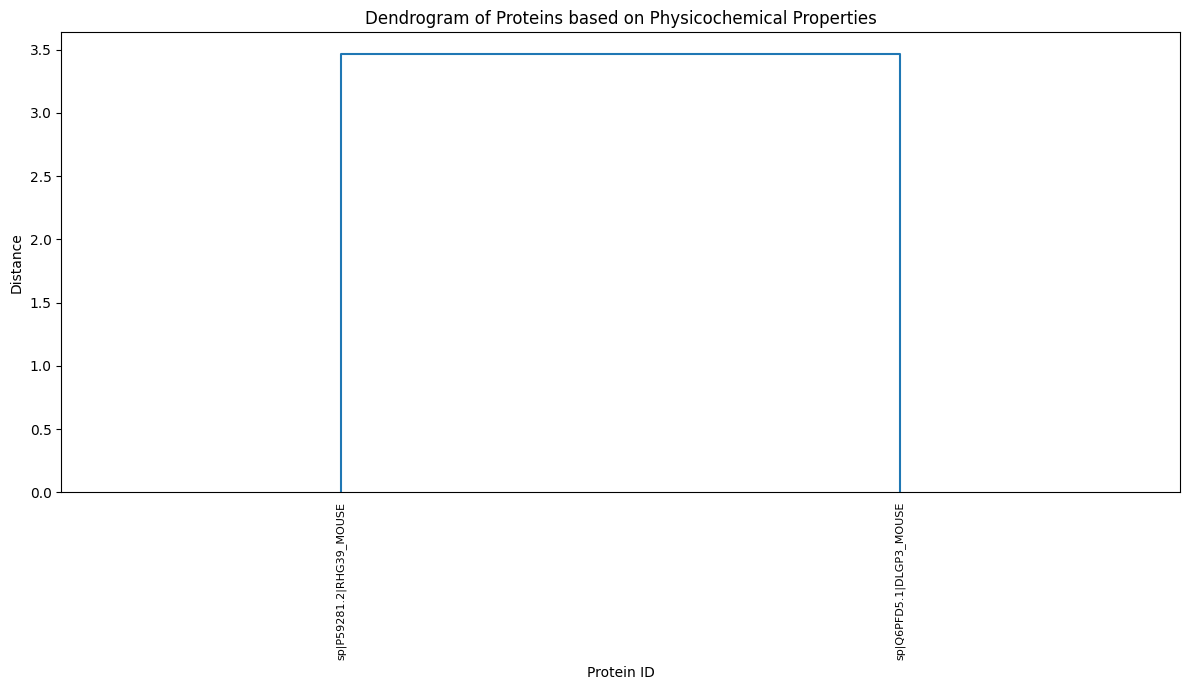


--- Analyzing Relationships based on Sequence Similarity ---


/usr/local/lib/python3.12/dist-packages/scipy/cluster/hierarchy.py:2947: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([0, dvw])


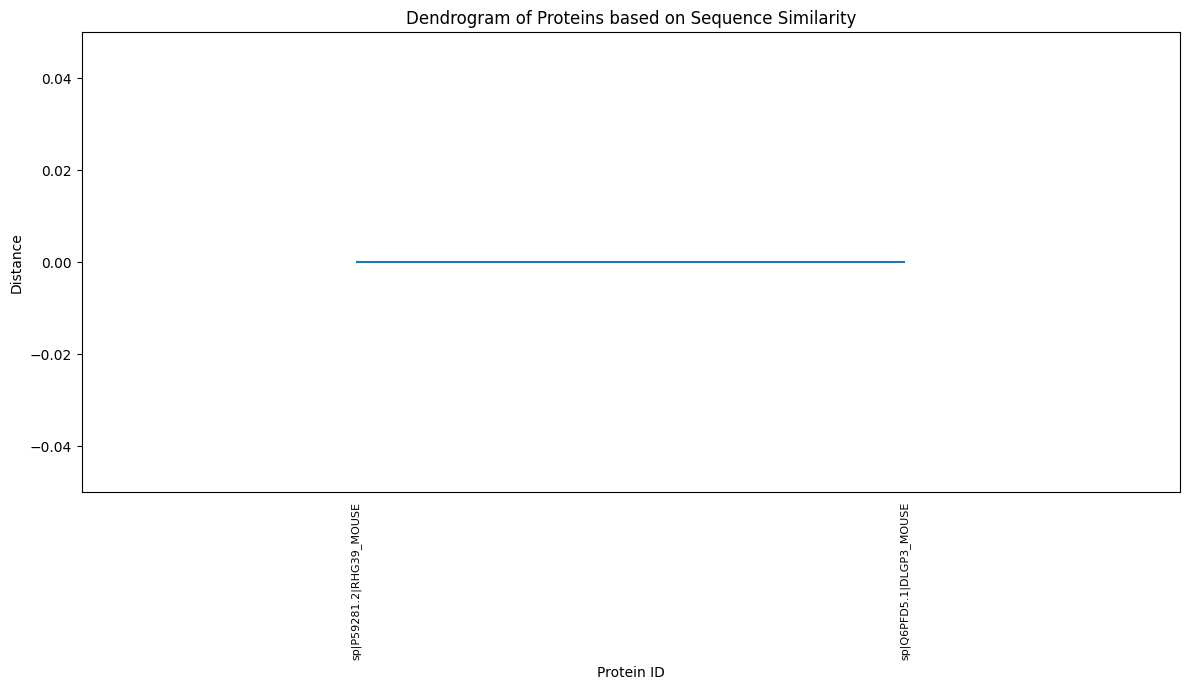


--- Analyzing Relationships based on Combined Properties and Similarity ---


/usr/local/lib/python3.12/dist-packages/scipy/cluster/hierarchy.py:2947: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([0, dvw])


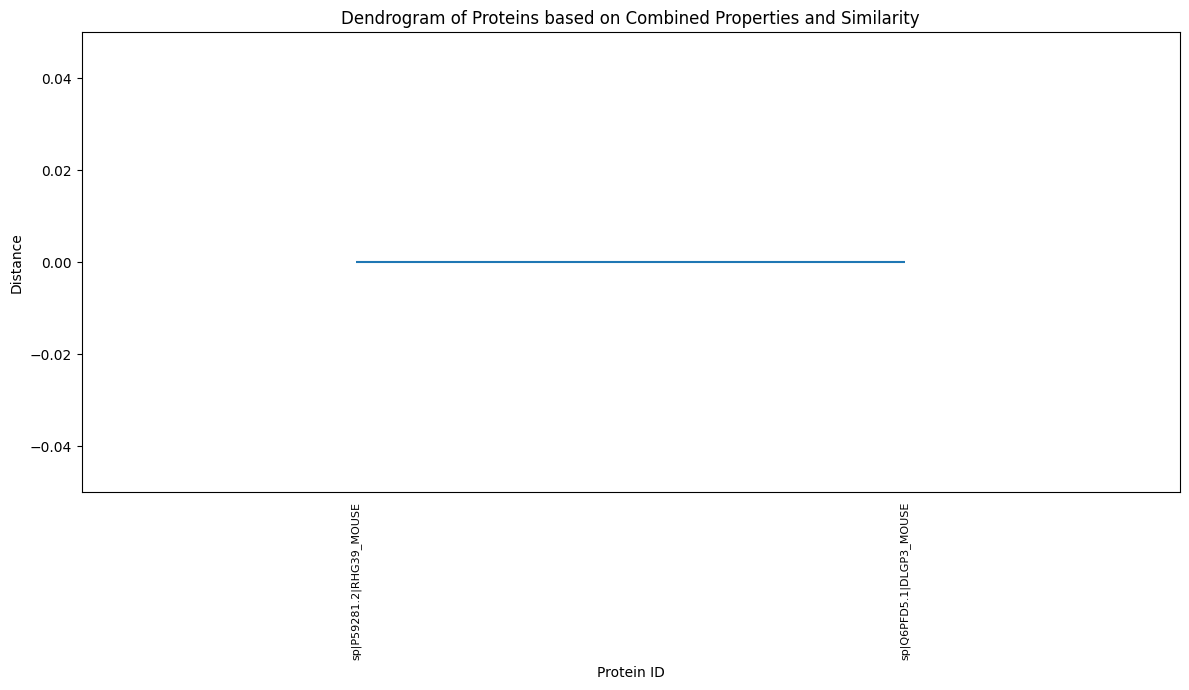

In [37]:

# Ensure protein_data_for_analysis is available and not empty
if 'protein_data_for_analysis' not in globals() or not protein_data_for_analysis:
    print("Error: No protein data found. Please run previous cells to load/analyze proteins.")
else:
    # Reconstruct properties_df from protein_data_for_analysis to ensure consistency
    summary_data = []
    for protein_data in protein_data_for_analysis:
        protein_id = protein_data['id']
        props = protein_data['properties']
        row_data = {'id': protein_id}
        row_data.update(props) # Add all calculated properties
        summary_data.append(row_data)

    if not summary_data:
        print("No protein properties were collected for analysis.")
        properties_df = pd.DataFrame() # Ensure it's defined even if empty
    else:
        properties_df = pd.DataFrame(summary_data)

    # Get ordered protein IDs for consistent indexing across analyses
    ordered_protein_ids = [p['id'] for p in protein_data_for_analysis]
    num_proteins = len(ordered_protein_ids)

    if num_proteins < 2:
        print("Need at least two protein sequences to perform clustering analyses.")
    else:
        # --- Helper function to get physicochemical distances ---
        def get_physchem_distances(properties_df, ordered_ids):
            # Ensure the properties_df is aligned with ordered_ids
            df_aligned = properties_df.set_index('id').reindex(ordered_ids).reset_index()
            # Select numerical features for clustering, excluding amino acid composition dictionary
            numeric_features_df = df_aligned[['length', 'molecular_weight', 'isoelectric_point']].copy()

            if numeric_features_df.empty or len(numeric_features_df) < 2:
                return None, None

            scaler = StandardScaler()
            scaled_features = scaler.fit_transform(numeric_features_df)
            return pdist(scaled_features, metric='euclidean'), ordered_ids

        # --- Helper function to get sequence distances ---
        def get_sequence_distances(similarity_df, ordered_ids):
            if similarity_df.empty or len(ordered_ids) < 2:
                return None, None

            num_proteins_ordered = len(ordered_ids)
            sequence_distance_matrix = np.zeros((num_proteins_ordered, num_proteins_ordered))
            id_to_index = {id_val: i for i, id_val in enumerate(ordered_ids)}

            max_score = similarity_df['Similarity_Score'].max()
            if max_score == 0:
                max_score = 1 # Avoid division by zero if all scores are 0

            for _, row in similarity_df.iterrows():
                # Only process if both proteins are in the ordered_ids list
                if row['Protein_A_ID'] in id_to_index and row['Protein_B_ID'] in id_to_index:
                    idx_a = id_to_index[row['Protein_A_ID']]
                    idx_b = id_to_index[row['Protein_B_ID']]
                    distance = max_score - row['Similarity_Score'] # Convert similarity to distance
                    sequence_distance_matrix[idx_a, idx_b] = distance
                    sequence_distance_matrix[idx_b, idx_a] = distance # Matrix is symmetric

            np.fill_diagonal(sequence_distance_matrix, 0)
            return squareform(sequence_distance_matrix), ordered_ids


        # --- 1. Relationship based on Physicochemical Properties ---
        print("\n--- Analyzing Relationships based on Physicochemical Properties ---")
        physchem_distances, physchem_labels = get_physchem_distances(properties_df, ordered_protein_ids)

        if physchem_distances is not None:
            physchem_linkage_matrix = linkage(physchem_distances, method='average')

            plt.figure(figsize=(12, 7))
            plt.title('Dendrogram of Proteins based on Physicochemical Properties')
            plt.xlabel('Protein ID')
            plt.ylabel('Distance')
            dendrogram(
                physchem_linkage_matrix,
                labels=physchem_labels,
                leaf_rotation=90.,
                leaf_font_size=8.,
            )
            plt.tight_layout()
            plt.savefig('physicochemical_dendrogram.png') # Save the plot
            plt.show()
        else:
            print("Not enough protein entries with physicochemical properties to perform clustering (at least 2 needed).")

        # --- 2. Relationship based on Sequence Similarity ---
        print("\n--- Analyzing Relationships based on Sequence Similarity ---")
        # Check if similarity_df exists in globals and is not empty
        if 'similarity_df' in globals() and not similarity_df.empty:
            sequence_distances, sequence_labels = get_sequence_distances(similarity_df, ordered_protein_ids)
            if sequence_distances is not None:
                sequence_linkage_matrix = linkage(sequence_distances, method='average')

                plt.figure(figsize=(12, 7))
                plt.title('Dendrogram of Proteins based on Sequence Similarity')
                plt.xlabel('Protein ID')
                plt.ylabel('Distance')
                dendrogram(
                    sequence_linkage_matrix,
                    labels=sequence_labels,
                    leaf_rotation=90.,
                    leaf_font_size=8.,
                )
                plt.tight_layout()
                plt.savefig('sequence_similarity_dendrogram.png') # Save the plot
                plt.show()
            else:
                print("Could not generate sequence distances. Check if similarity_df contains enough valid protein pairs or if enough proteins are loaded.")
        else:
            print("No sequence similarity data found or not enough proteins for clustering (at least 2 needed).")

        # --- 3. Relationship based on Combined Physicochemical Properties and Sequence Similarity ---
        print("\n--- Analyzing Relationships based on Combined Properties and Similarity ---")

        # Only proceed if both types of distances can be calculated for at least 2 proteins
        physchem_distances_combined, _ = get_physchem_distances(properties_df, ordered_protein_ids)
        sequence_distances_combined, _ = None, None # Initialize for the combined check

        if 'similarity_df' in globals() and not similarity_df.empty:
             sequence_distances_combined, _ = get_sequence_distances(similarity_df, ordered_protein_ids)

        if physchem_distances_combined is not None and sequence_distances_combined is not None:
            # Normalize distances to a 0-1 range before combining
            norm_physchem_dist = (physchem_distances_combined - physchem_distances_combined.min()) / (physchem_distances_combined.max() - physchem_distances_combined.min() if (physchem_distances_combined.max() - physchem_distances_combined.min()) != 0 else 1)
            norm_sequence_dist = (sequence_distances_combined - sequence_distances_combined.min()) / (sequence_distances_combined.max() - sequence_distances_combined.min() if (sequence_distances_combined.max() - sequence_distances_combined.min()) != 0 else 1)

            # Combine distances (e.g., by averaging)
            combined_distances = (norm_physchem_dist + norm_sequence_dist) / 2

            # Perform hierarchical clustering
            combined_linkage_matrix = linkage(combined_distances, method='average')

            # Plot dendrogram
            plt.figure(figsize=(12, 7))
            plt.title('Dendrogram of Proteins based on Combined Properties and Similarity')
            plt.xlabel('Protein ID')
            plt.ylabel('Distance')
            dendrogram(
                combined_linkage_matrix,
                labels=ordered_protein_ids,
                leaf_rotation=90.,
                leaf_font_size=8.,
            )
            plt.tight_layout()
            plt.savefig('combined_dendrogram.png') # Save the plot
            plt.show()
        else:
            print("Not enough data to perform combined analysis (at least 2 proteins with both physicochemical properties and sequence similarity data needed).")

# Export and Download Results

In [ ]:


print("---\nExporting and Archiving Results\n---")

# Define filenames
excel_filename = 'protein_analysis_summary.xlsx'
zip_filename = 'protein_analysis_results.zip'

# Create an Excel writer object
with pd.ExcelWriter(excel_filename, engine='xlsxwriter') as writer:
    # Export Physicochemical Properties to a sheet
    if 'properties_df' in globals() and not properties_df.empty:
        properties_df.to_excel(writer, sheet_name='Physicochemical Properties', index=False)
        print(f"'Physicochemical properties' saved to '{excel_filename}' (sheet 'Physicochemical Properties')")
    else:
        print("No 'properties_df' found or it is empty. Skipping export of physicochemical properties to Excel.")

    # Export Sequence Similarity to a sheet
    if 'similarity_df' in globals() and not similarity_df.empty:
        similarity_df.to_excel(writer, sheet_name='Sequence Similarity', index=False)
        print(f"'Sequence similarity' saved to '{excel_filename}' (sheet 'Sequence Similarity')")
    else:
        print("No 'similarity_df' found or it is empty. Skipping export of sequence similarity to Excel.")

print(f"Excel file '{excel_filename}' created.")

# Create a ZIP archive and add the Excel file and dendrogram images
with zipfile.ZipFile(zip_filename, 'w') as zf:
    zf.write(excel_filename)
    print(f"'{excel_filename}' added to '{zip_filename}'.")

    # List of dendrogram image files to include
    dendrogram_files = [
        'physicochemical_dendrogram.png',
        'sequence_similarity_dendrogram.png'
    ]

    for img_file in dendrogram_files:
        if os.path.exists(img_file):
            zf.write(img_file)
            print(f"'{img_file}' added to '{zip_filename}'.")
        else:
            print(f"Warning: Dendrogram image '{img_file}' not found. Skipping addition to ZIP.")

print(f"ZIP archive '{zip_filename}' created.")

# Download the ZIP file
files.download(zip_filename)

print("\nExport and download process complete. Please check your browser's downloads for the ZIP archive containing all results.")

# Prepare for next run

Finally, it is important to run this cell starting a new analysis without interference from previous runs. This cell provides a utility to clear all previously loaded and analyzed protein data from the current session.

In [24]:
all_fasta_sequences = []
print("Data in 'all_fasta_sequences' has been cleared.")

protein_data_for_analysis = []
print("Data in 'protein_data_for_analysis' has been cleared.")

# Clear additional data structures for a fresh start
if 'properties_df' in globals():
    del properties_df
    print("'properties_df' has been cleared.")
if 'similarity_df' in globals():
    del similarity_df
    print("'similarity_df' has been cleared.")


Data in 'all_fasta_sequences' has been cleared.
Data in 'protein_data_for_analysis' has been cleared.
'properties_df' has been cleared.
'similarity_df' has been cleared.
